# 04 - Modeling: Depression Prediction
**Obiettivo:** Selezionare e addestrare il modello finale per la predizione del punteggio PHQ-9. Effettueremo un confronto di base tra un modello lineare (Ridge) e un Gradient Boosting avanzato (LightGBM), seguito da Hyperparameter Tuning sul miglior candidato tramite Optuna (K-Fold CV).

- **Baseline**: Ridge Regression
- **Candidato**: LightGBM (metodo di boosting sequenziale ad altissime prestazioni, gestione ottimale dei missing values, robusto per relazioni non lineari)

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, GroupKFold, cross_validate
from sklearn.linear_model import Ridge
import lightgbm as lgb
import optuna
import shap
import joblib
import json

# Riproducibilità
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Caricamento Dati
Carichiamo eslusivamente il `train.csv`. Il `test.csv` rimane intoccato per evitare bias di selezione del modello.

In [8]:
DATA_DIR = '../data/processed'
FIGURES_DIR = '../../../docs/latex/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

TARGET_COL = 'phq9_total'
EXCLUDE_COLS = [TARGET_COL, 'user_id', 'user_id', 'date']
FEATURES = [c for c in train_df.columns if c not in EXCLUDE_COLS]

X_train = train_df[FEATURES]
y_train = train_df[TARGET_COL]

print(f"Righe training: {X_train.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Righe training: 80000
Features: 8


## 2. Definizione Baseline (Ridge Regression)
Stabiliamo le metriche di base usando la Ridge Regression valutata tramite KFold (5 splits).

In [9]:
ridge_model = Ridge(alpha=1.0, random_state=SEED)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_res_baseline = cross_validate(
    ridge_model, X_train, y_train, cv=kf, 
    scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error')
)

ridge_mae = -np.mean(cv_res_baseline['test_neg_mean_absolute_error'])
ridge_rmse = -np.mean(cv_res_baseline['test_neg_root_mean_squared_error'])

print(f"Baseline Ridge Regression CV Mean MAE:  {ridge_mae:.4f}")
print(f"Baseline Ridge Regression CV Mean RMSE: {ridge_rmse:.4f}")

baseline_metrics = {
    'model': 'Ridge(alpha=1.0)',
    'metrics': {
        'MAE_mean': ridge_mae,
        'MAE_std': float(np.std(cv_res_baseline['test_neg_mean_absolute_error'])),
        'RMSE_mean': ridge_rmse,
        'RMSE_std': float(np.std(cv_res_baseline['test_neg_root_mean_squared_error']))
    }
}
with open(os.path.join(DATA_DIR, 'baseline_metrics.json'), 'w') as f:
    json.dump(baseline_metrics, f, indent=4)

Baseline Ridge Regression CV Mean MAE:  2.6716
Baseline Ridge Regression CV Mean RMSE: 3.3799


## 3. LightGBM & Optuna Hyperparameter Tuning
Usiamo **Optuna** per trovare iperparametri ottimali (learning rate, profondità, max_bin, colsample), con 50 trials per rimanere nei tempi operativi prescritti.

In [10]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': SEED,
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    kf_opt = KFold(n_splits=3, shuffle=True, random_state=SEED)
    maes = []
    
    for train_idx, val_idx in kf_opt.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
        )
        
        preds = model.predict(X_va)
        mae = np.mean(np.abs(preds - y_va))
        maes.append(mae)
        
    return np.mean(maes)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
print("Esecuzione Optuna per 50 trials...")
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['objective'] = 'regression'
best_params['random_state'] = SEED
print(f"\nMigliori Parametri Optuna:\n{best_params}")
print(f"MAE Optuna (CV media): {study.best_value:.4f}")

Esecuzione Optuna per 50 trials...

Migliori Parametri Optuna:
{'n_estimators': 142, 'learning_rate': 0.09400642525943469, 'num_leaves': 42, 'max_depth': 7, 'min_child_samples': 50, 'subsample': 0.784684925376458, 'colsample_bytree': 0.8311477626455183, 'objective': 'regression', 'random_state': 42}
MAE Optuna (CV media): 2.2118


## 4. Addestramento Finale (LightGBM)
Addestriamo il LightGBM con i migliori parametri trovati su tutto il Training Set. Usiamo pesi per penalizzare l'errore sui pazienti più gravi.

In [11]:
sample_weights = np.where(y_train >= 15, 2.0, 1.0)

best_lgb = lgb.LGBMRegressor(**best_params)
best_lgb.fit(X_train, y_train, sample_weight=sample_weights)

# Salvataggio Modello
model_path = os.path.join(DATA_DIR, 'final_model.pkl')
joblib.dump(best_lgb, model_path)

print(f"Modello LightGBM salvato con successo in {model_path}")

Modello LightGBM salvato con successo in ../data/processed\final_model.pkl


## 5. SHAP Feature Importance
Estraiamo i valori SHAP per capire l'impatto direzionale delle misurazioni dell'umore sull'allarme clinico.

C:\Users\aless\AppData\Local\Temp\ipykernel_17708\2982250887.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type='dot', show=False)


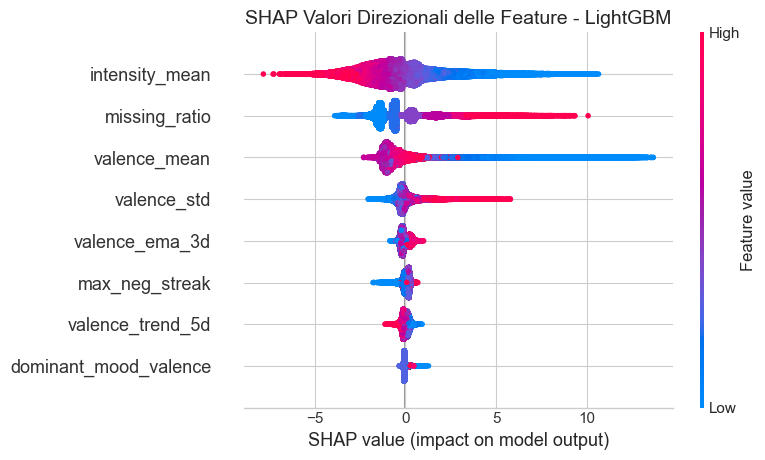

In [12]:
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_train)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, plot_type='dot', show=False)
plt.title('SHAP Valori Direzionali delle Feature - LightGBM', fontsize=14)

fig_path = os.path.join(FIGURES_DIR, 'dp_feature_importance.png')  # Sovrascriviamo l'immagine esistente
plt.tight_layout()
plt.savefig(fig_path, bbox_inches='tight', dpi=300)
plt.show()